In [1]:
import gzip
import pickle
import glob
import os
from metient.util.globals import *
from metient.util import plotting_util as plutil
import seaborn as sns
import matplotlib.pyplot as plt

DATASET_NAMES = [ "HGSOC", "Melanoma",]
# Change this to the path for the reproducibility data directory on your system
REPRO_DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility"
CALIBRATE_DIRS = [os.path.join(REPRO_DATA_DIR,f"hgsoc/metient_outputs/genetic_organotrop_calibration"),
                  os.path.join(REPRO_DATA_DIR,f"melanoma/metient_outputs/genetic_organotrop_calibration"),]

OUTPUT_DIR = "/data1/morrisq/divyak/projects/metient/notebooks/output_plots"


### Load genetic distance and organotropism losses for all patients with both (and more than one pareto optimal history)

In [2]:
pt_to_distributions = {}
for dataset_name, calibrate_dir in zip(DATASET_NAMES, CALIBRATE_DIRS):
    matching_files = glob.glob(f'{calibrate_dir}/*pkl.gz')
    print("Loading", len(matching_files), "files for", dataset_name)
    for fn in matching_files:
        with gzip.open(fn, 'rb') as f:
            pkl = pickle.load(f)
        run_name = fn.split("/")[-1].replace(".pkl.gz", "").replace("_"," ").replace("calibrate","")
        run_name = f"{dataset_name}: \n Pt. {run_name}"
        loss_dicts = pkl[OUT_LOSS_DICT_KEY]
        if len(loss_dicts) == 1:
            continue

        organo_distribution = []
        gen_dist_distribution = []
        for loss_dict in loss_dicts:
            organo_distribution.append(loss_dict[ORGANOTROP_KEY])
            gen_dist_distribution.append(loss_dict[GEN_DIST_KEY])
        
        print("\n",run_name)
        print("Organot losses:", [f"{x:.2f}" for x in organo_distribution])
        print("Genetic losses:",[f"{x:.2f}" for x in gen_dist_distribution])
        if all(x == 0.0 for x in organo_distribution):
            organo_distribution = None
        else:
            organo_distribution = plutil.losses_to_probabilities(organo_distribution)
            print("Organot probs:",[f"{x:.2f}" for x in organo_distribution])
        gen_dist_distribution = plutil.losses_to_probabilities(gen_dist_distribution)
        
        print("Genetic probs:",[f"{x:.2f}" for x in gen_dist_distribution])
        
        pt_to_distributions[run_name] = [organo_distribution,gen_dist_distribution]

Loading 13 files for HGSOC

 HGSOC: 
 Pt. 7  Left Ovary
Organot losses: ['0.65', '1.33', '1.69', '1.57']
Genetic losses: ['2.26', '2.06', '2.26', '2.30']
Organot probs: ['0.63', '0.17', '0.09', '0.11']
Genetic probs: ['0.12', '0.67', '0.12', '0.09']

 HGSOC: 
 Pt. 1  Right Ovary
Organot losses: ['1.81', '1.84', '1.85']
Genetic losses: ['3.23', '3.23', '3.27']
Organot probs: ['0.73', '0.18', '0.10']
Genetic probs: ['0.47', '0.47', '0.06']

 HGSOC: 
 Pt. 7  Right Ovary
Organot losses: ['1.08', '1.56', '1.47']
Genetic losses: ['1.99', '2.22', '2.26']
Organot probs: ['0.75', '0.10', '0.15']
Genetic probs: ['0.75', '0.14', '0.10']

 HGSOC: 
 Pt. 3  Right Ovary
Organot losses: ['1.50', '1.97']
Genetic losses: ['3.03', '3.07']
Organot probs: ['0.88', '0.12']
Genetic probs: ['0.88', '0.12']
Loading 7 files for Melanoma

 Melanoma: 
 Pt. D  Primary, right ankle
Organot losses: ['0.84', '1.10']
Genetic losses: ['1.01', '1.08']
Organot probs: ['0.88', '0.12']
Genetic probs: ['0.88', '0.12']


### Plot the distributions

HGSOC: 
 Pt. 7  Left Ovary
HGSOC: 
 Pt. 1  Right Ovary
HGSOC: 
 Pt. 7  Right Ovary
HGSOC: 
 Pt. 3  Right Ovary
Melanoma: 
 Pt. D  Primary, right ankle


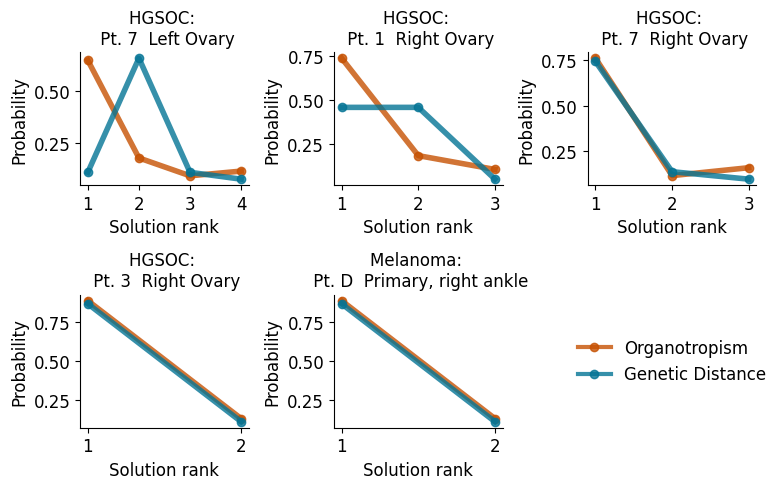

In [3]:

# Create figure with subplots
n_plots = len(pt_to_distributions)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2.5*n_rows))
plt.subplots_adjust(hspace=0.7, wspace=0.5)

axes = axes.flatten()

for idx, (pt, distributions) in enumerate(pt_to_distributions.items()):
    print(pt)
    organo_distribution, gen_dist_distribution = distributions[0], distributions[1]
    
    # Plot probabilities vs indices
    ax = axes[idx]
    x_indices = range(1,len(gen_dist_distribution)+1)
    
    # Add tiny jitter to avoid overlap when values are the same
    jitter = 0.01
    
    gen_dist_jittered = [x - jitter for x in gen_dist_distribution]
    
    if organo_distribution is not None:
        # Plot organotropism distribution
        organo_jittered = [x + jitter for x in organo_distribution]
        ax.plot(x_indices, organo_jittered, 'o-', color='#c65102', label='Organotropism',linewidth=4, alpha=0.8)
        
    # Plot genetic distance distribution
    ax.plot(x_indices, gen_dist_jittered, 'o-', color='#047495', label='Genetic Distance',linewidth=4, alpha=0.8)
    
    ax.set_xlabel('Solution rank', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_title(f'{pt}')
    for spine in ax.spines:
        if spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    
# Create legend in last subplot
legend_ax = axes[-1]
legend_ax.set_visible(True)
legend_ax.axis('off')

# Create dummy lines for legend
from matplotlib.lines import Line2D
organo_line = Line2D([0], [0], color='#c65102', linewidth=3, marker='o', label='Organotropism', alpha=0.8)
genetic_line = Line2D([0], [0], color='#047495', linewidth=3, marker='o', label='Genetic Distance', alpha=0.8)

# Add legend
legend_ax.legend(handles=[organo_line, genetic_line], 
                loc='center',
                frameon=False,
                fontsize=12)
plt.savefig(os.path.join(OUTPUT_DIR, 'organo_vs_gen_dist_distributions.png'), bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()


### See how the weights change based on calibration type

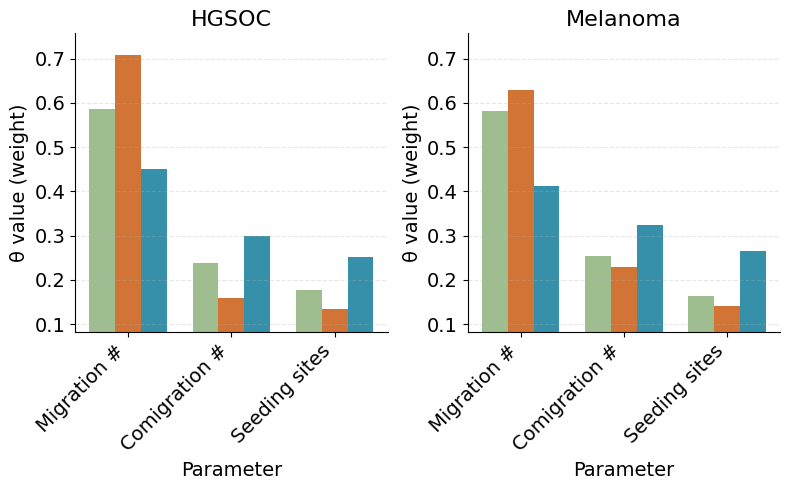

In [4]:
import json
import numpy as np

melanoma_dirs = [os.path.join(REPRO_DATA_DIR,"melanoma/metient_outputs/genetic_organotrop_calibration"),
                os.path.join(REPRO_DATA_DIR,"melanoma/metient_outputs/organotrop_calibration"),
                os.path.join(REPRO_DATA_DIR,"melanoma/metient_outputs/genetic_calibration"),]

hgsoc_dirs = [os.path.join(REPRO_DATA_DIR,"hgsoc/metient_outputs/genetic_organotrop_calibration"),
                os.path.join(REPRO_DATA_DIR,"hgsoc/metient_outputs/organotrop_calibration"),
                os.path.join(REPRO_DATA_DIR,"hgsoc/metient_outputs/genetic_calibration"),]

calibration_types = ["Both", "Organotropism", "Genetic distance"]
theta_labels = ["Migration #", "Comigration #", "Seeding sites"]
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,5))

# Plot melanoma data
hgsoc_theta = []
for dir in hgsoc_dirs:
    with open(os.path.join(dir, "best_theta.json")) as f:
        hgsoc_theta.append(json.load(f))

x = np.arange(len(theta_labels))
width = 0.25
colors = ['#87ae73', '#c65102', '#047495']

for i, (theta, cal_type) in enumerate(zip(hgsoc_theta, calibration_types)):
    ax1.bar(x + i*width, theta, width, label=cal_type, color=colors[i], alpha=0.8)

ax1.set_xlabel('Parameter', fontsize=14)
ax1.set_ylabel('θ value (weight)', fontsize=14)
ax1.set_title('HGSOC', fontsize=16, pad=5)

# Remove spines
for spine in ax1.spines:
    if spine in ['top', 'right']:
        ax1.spines[spine].set_visible(False)
    
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_xticks(x + width)
ax1.set_xticklabels(theta_labels, rotation=45, ha='right',fontsize=14)

# Plot HGSOC data  
melanoma_theta = []
for dir in melanoma_dirs:
    with open(os.path.join(dir, "best_theta.json")) as f:
        melanoma_theta.append(json.load(f))

for i, (theta, cal_type) in enumerate(zip(melanoma_theta, calibration_types)):
    ax2.bar(x + i*width, theta, width, label=cal_type, color=colors[i], alpha=0.8)

ax2.set_xlabel('Parameter', fontsize=14)
ax2.set_ylabel('θ value (weight)', fontsize=14)
ax2.set_title('Melanoma', fontsize=16, pad=5)

# Remove spines
for spine in ax2.spines:
    if spine in ['top', 'right']:
        ax2.spines[spine].set_visible(False)
    
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_xticks(x + width)
ax2.set_xticklabels(theta_labels, rotation=45, ha='right',fontsize=14)

# Set y limits based on max theta value across both plots
min_theta = min([min(min(theta) for theta in hgsoc_theta), 
                 min(min(theta) for theta in melanoma_theta)])
max_theta = max([max(max(theta) for theta in hgsoc_theta), 
                 max(max(theta) for theta in melanoma_theta)])
ax1.set_ylim(min_theta-0.05, max_theta + 0.05)
ax2.set_ylim(min_theta-0.05, max_theta + 0.05)
ax1.tick_params(axis='y', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)


# ax1.legend(frameon=False, bbox_to_anchor=(0.5, 1.15), loc='center', ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'theta_comparison_organo_gd_both.png'), 
            bbox_inches='tight', dpi=300)
plt.show()


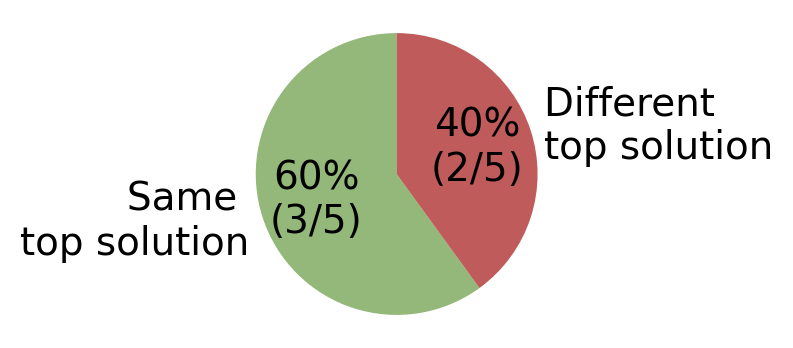

In [5]:
# Create a pie chart showing proportion of patients with same top solution
plt.figure(figsize=(2,2),dpi=200)
labels = ['Same \ntop solution', 'Different \ntop solution'] 
sizes = [3, 2]  # 3/5 same, 2/5 different
colors = ['#78A659', '#B13233']  # Green for same, red for different
plt.pie(sizes, labels=labels, colors=colors, autopct=lambda p: f'{p:.0f}%\n({int(p*sum(sizes)/100)}/{sum(sizes)})',
        startangle=90, wedgeprops={"alpha": 0.8}, textprops={'fontsize': 14})

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

plt.savefig(os.path.join(OUTPUT_DIR, 'same_solution_proportion_pie.svg'),
            bbox_inches='tight', dpi=300)
plt.show()
